In [1]:
import pandas as pd
import numpy as np
url = "https://raw.githubusercontent.com/GeethaGunasekaran1/Dataset_rep/main/social_media_engagement_5000.csv"
df = pd.read_csv(url)
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [2]:
df.columns.tolist()

['user_id',
 'age',
 'gender',
 'country',
 'post_id',
 'post_type',
 'post_category',
 'likes',
 'comments',
 'shares',
 'watch_time_sec',
 'impression_count',
 'posted_at',
 'follower_count',
 'is_verified',
 'device_type',
 'sentiment',
 'hashtags',
 'engagement_rate']

In [3]:
df.dtypes

user_id               int64
age                 float64
gender                  str
country                 str
post_id               int64
post_type               str
post_category           str
likes               float64
comments            float64
shares              float64
watch_time_sec        int64
impression_count      int64
posted_at               str
follower_count        int64
is_verified            bool
device_type             str
sentiment               str
hashtags                str
engagement_rate     float64
dtype: object

In [4]:
df['posted_at'] = pd.to_datetime(df['posted_at'], dayfirst=True)
df['posted_at'].dtype

dtype('<M8[us]')

In [5]:
df['posted_at'].head()

0   2022-12-17
1   2023-06-02
2   2023-05-07
3   2023-02-12
4   2023-05-23
Name: posted_at, dtype: datetime64[us]

In [6]:
df.isnull().sum()

user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64

In [7]:
df['age'] = df['age'].fillna(df['age'].median())
df['likes'] = df['likes'].fillna(df['likes'].median())
df['comments'] = df['comments'].fillna(df['comments'].median())
df['shares'] = df['shares'].fillna(df['shares'].median())

df['gender'] = df['gender'].fillna(df['gender'].mode()[0])
df['sentiment'] = df['sentiment'].fillna(df['sentiment'].mode()[0])

df.isnull().sum()    

user_id             0
age                 0
gender              0
country             0
post_id             0
post_type           0
post_category       0
likes               0
comments            0
shares              0
watch_time_sec      0
impression_count    0
posted_at           0
follower_count      0
is_verified         0
device_type         0
sentiment           0
hashtags            0
engagement_rate     0
dtype: int64

In [8]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicate rows after removal:", df.duplicated().sum())
print("New Shape:", df.shape)

Duplicate rows: 0
Duplicate rows after removal: 0
New Shape: (5000, 19)


In [9]:
print("Gender:", df['gender'].unique())
print("Sentiment:", df['sentiment'].unique())
print("Post Type:", df['post_type'].unique())
print("Country:", df['country'].unique())
print("Device Type:", df['device_type'].unique())

Gender: <ArrowStringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str
Sentiment: <ArrowStringArray>
['negative', 'positive', 'neutral']
Length: 3, dtype: str
Post Type: <ArrowStringArray>
['image', 'reel', 'text', 'video']
Length: 4, dtype: str
Country: <ArrowStringArray>
[   'Brazil',        'UK',    'France',    'Canada',     'Japan', 'Australia',
     'India',       'UAE',   'Germany',       'USA']
Length: 10, dtype: str
Device Type: <ArrowStringArray>
['mobile', 'tablet', 'desktop']
Length: 3, dtype: str


In [10]:
print(df[['likes', 'comments', 'shares']].describe())
print("\nNegative likes:", (df['likes'] < 0).sum())
print("Negative comments:", (df['comments'] < 0).sum())
print("Negative shares:", (df['shares'] < 0).sum())

              likes     comments     shares
count   5000.000000  5000.000000  5000.0000
mean   10106.997400  1502.039800  1002.9106
std     5702.293017   856.393312   570.8552
min       10.000000     0.000000     0.0000
25%     5235.000000   792.000000   511.0000
50%    10105.500000  1497.000000  1012.0000
75%    14959.000000  2235.250000  1483.0000
max    19998.000000  2999.000000  1999.0000

Negative likes: 0
Negative comments: 0
Negative shares: 0


In [11]:
print(df['hashtags'].head())

0    #foodie #travel #love
1                 #fitness
2                  #foodie
3      #music #foodie #fun
4                  #travel
Name: hashtags, dtype: str


In [12]:
df['hashtag_count'] = df['hashtags'].apply(lambda x: len(x.split()))
df[['hashtags', 'hashtag_count']].head()

,hashtags,hashtag_count
0,#foodie #travel #love,3
1,#fitness,1
2,#foodie,1
3,#music #foodie #fun,3
4,#travel,1


In [13]:
print(df['sentiment'].apply(lambda x: repr(x)).unique())

<ArrowStringArray>
[''negative'', ''positive'', ''neutral'']
Length: 3, dtype: str


In [14]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nHead:")
print(df.head())
print("\nTail:")
print(df.tail())

Shape: (5000, 20)

Columns: ['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate', 'hashtag_count']

Head:
   user_id   age  gender country  post_id post_type post_category    likes  \
0    25795  43.0  Female  Brazil   496713     image       fitness   7011.0   
1    10860  33.0    Male  Brazil   157326      reel          food  11750.0   
2    86820  32.0  Female      UK   109864      text          food   4862.0   
3    64886  51.0   Other  France   848877      text       fitness   5350.0   
4    16265  34.0   Other      UK   449706     image       fitness  12682.0   

   comments  shares  watch_time_sec  impression_count  posted_at  \
0     354.0  1157.0            5726             44650 2022-12-17   
1    2606.0  1807.0            5947             80216 2023-06-02   
2     344.0   955.0 

In [15]:
df.info()
print("\nSummary Statistics:")
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   float64       
 2   gender            5000 non-null   str           
 3   country           5000 non-null   str           
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   str           
 6   post_category     5000 non-null   str           
 7   likes             5000 non-null   float64       
 8   comments          5000 non-null   float64       
 9   shares            5000 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[us]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 non-null   b

In [16]:
print(df[df['engagement_rate'] > 10].shape[0])
print(df[df['engagement_rate'] > 10][['likes', 'comments', 'shares', 'follower_count', 'engagement_rate']].head(10))

68
       likes  comments  shares  follower_count  engagement_rate
11   19856.0    1723.0   905.0          365517        12.381057
13   15700.0    1434.0  1886.0           51929        48.894602
144  15055.0    1253.0  1616.0          219353       121.931973
145  19311.0     415.0   607.0          190168        87.266094
199   8634.0    2588.0  1644.0          461336        24.837838
238  19290.0    2003.0   842.0          545948        21.161568
251  15342.0    1014.0   737.0          798384        35.026639
541   7736.0    1681.0   887.0          731165        92.828829
554  18513.0    2090.0  1420.0          566668       191.504348
617  19143.0    1497.0   646.0          244297        15.595409


In [17]:
print(df['engagement_rate'].quantile([0.95, 0.99, 0.999]))

0.950     2.328526
0.990    13.672022
0.999    77.170279
Name: engagement_rate, dtype: float64


In [18]:
cap_value = df['engagement_rate'].quantile(0.99)
df['engagement_rate'] = np.where(df['engagement_rate'] > cap_value, cap_value, df['engagement_rate'])
print(df['engagement_rate'].describe())

count    5000.000000
mean        0.695353
std         1.737850
min         0.006363
25%         0.145781
50%         0.253896
75%         0.504794
max        13.672022
Name: engagement_rate, dtype: float64


In [19]:
print("Post type counts:\n", df['post_type'].value_counts())
print("nSentiment counts:\n", df['sentiment'].value_counts())
print("\nCountry counts:\n", df['country'].value_counts())
print("\nUnique post categories:\n", df['post_category'].unique())
print("Number of unique countries:", df['country'].nunique())

Post type counts:
 post_type
reel     1283
image    1247
text     1245
video    1225
Name: count, dtype: int64
nSentiment counts:
 sentiment
positive    2513
neutral     1527
negative     960
Name: count, dtype: int64

Country counts:
 country
India        535
Canada       513
Brazil       504
UAE          503
USA          501
France       496
UK           493
Australia    493
Germany      490
Japan        472
Name: count, dtype: int64

Unique post categories:
 <ArrowStringArray>
[  'fitness',      'food',      'tech',    'travel',   'fashion', 'lifestyle',
 'education',     'music']
Length: 8, dtype: str
Number of unique countries: 10


In [20]:
numeric_cols = ['age', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'follower_count', 'engagement_rate', 'hashtag_count']
corr_matrix = df[numeric_cols].corr()
print(corr_matrix)
print("n\Avg likes by most post type:\n", df.groupby('post_type')['likes'].mean())
print("n\Avg impression by country:\n", df.groupby('country')['impression_count'].mean())      

                       age     likes  comments    shares  watch_time_sec  \
age               1.000000 -0.036322 -0.007284  0.013871        0.005542   
likes            -0.036322  1.000000 -0.018421  0.004712        0.008710   
comments         -0.007284 -0.018421  1.000000  0.006142       -0.016351   
shares            0.013871  0.004712  0.006142  1.000000        0.014658   
watch_time_sec    0.005542  0.008710 -0.016351  0.014658        1.000000   
impression_count  0.013322  0.007952 -0.009395 -0.005204       -0.004335   
follower_count   -0.024894 -0.022982 -0.011733 -0.010783        0.002761   
engagement_rate   0.002555  0.170620  0.002624  0.027388        0.010332   
hashtag_count     0.007173 -0.002190 -0.015230  0.013379       -0.023301   

                  impression_count  follower_count  engagement_rate  \
age                       0.013322       -0.024894         0.002555   
likes                     0.007952       -0.022982         0.170620   
comments                 -

In [21]:
df['engagement_score'] = df['likes'] + (df['comments'] * 2) + (df['shares'] * 3)
df[['likes', 'comments', 'shares', 'engagement_score']].head()

,likes,comments,shares,engagement_score
0,7011.0,354.0,1157.0,11190.0
1,11750.0,2606.0,1807.0,22383.0
2,4862.0,344.0,955.0,8415.0
3,5350.0,1083.0,1049.0,10663.0
4,12682.0,2735.0,1300.0,22052.0


In [22]:
print("Avg engagement_score by post_type:\n", df.groupby('post_type')['engagement_score'].mean())
print("\nAvg engagement_score by country:\n", df.groupby('country')['engagement_score'].mean())
print("Avg engagement_score by sentiment:\n", df.groupby('sentiment')['engagement_score'].mean())

Avg engagement_score by post_type:
 post_type
image    16213.205293
reel     15992.302806
text     16140.328916
video    16137.422857
Name: engagement_score, dtype: float64

Avg engagement_score by country:
 country
Australia    16354.812373
Brazil       15894.135913
Canada       16144.968811
France       16485.704637
Germany      16114.250000
India        16058.251402
Japan        16027.786017
UAE          16277.143141
UK           15818.779919
USA          16023.702595
Name: engagement_score, dtype: float64
Avg engagement_score by sentiment:
 sentiment
negative    16262.208333
neutral     15969.698101
positive    16156.623558
Name: engagement_score, dtype: float64


In [23]:
cols = ['likes', 'comments', 'shares', 'watch_time_sec', 'engagement_rate', 'follower_count']
for col in cols:
    print(f"--- {col} ---")
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Mode:", df[col].mode()[0])
    print("Std Dev:", df[col].std())
    print("Variation:", df[col].var())
    print("25th percentile:", df[col].quantile(0.25))
    print("75th percentile:", df[col].quantile(0.75))

--- likes ---
Mean: 10106.9974
Median: 10105.5
Mode: 10105.5
Std Dev: 5702.293017183877
Variation: 32516145.65382401
25th percentile: 5235.0
75th percentile: 14959.0
--- comments ---
Mean: 1502.0398
Median: 1497.0
Mode: 1497.0
Std Dev: 856.3933120458984
Variation: 733409.5049169434
25th percentile: 792.0
75th percentile: 2235.25
--- shares ---
Mean: 1002.9106
Median: 1012.0
Mode: 1012.0
Std Dev: 570.8551999758852
Variation: 325875.65933950787
25th percentile: 511.0
75th percentile: 1483.0
--- watch_time_sec ---
Mean: 4014.5032
Median: 4034.5
Mode: 916
Std Dev: 2308.0964590420845
Variation: 5327309.264242608
25th percentile: 2017.75
75th percentile: 6020.25
--- engagement_rate ---
Mean: 0.6953527482374011
Median: 0.2538959065
Mode: 13.672022423500103
Std Dev: 1.7378498802673585
Variation: 3.0201222063452726
25th percentile: 0.14578108750000002
75th percentile: 0.504793702
--- follower_count ---
Mean: 393698.2248
Median: 388982.0
Mode: 497502
Std Dev: 230927.88453461003
Variation: 533276

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

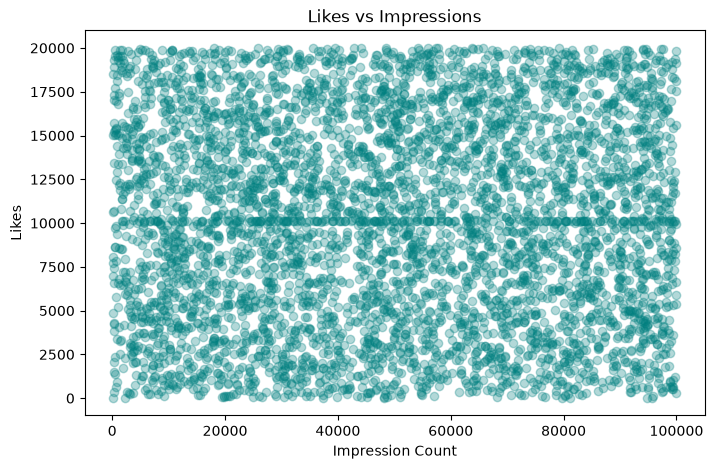

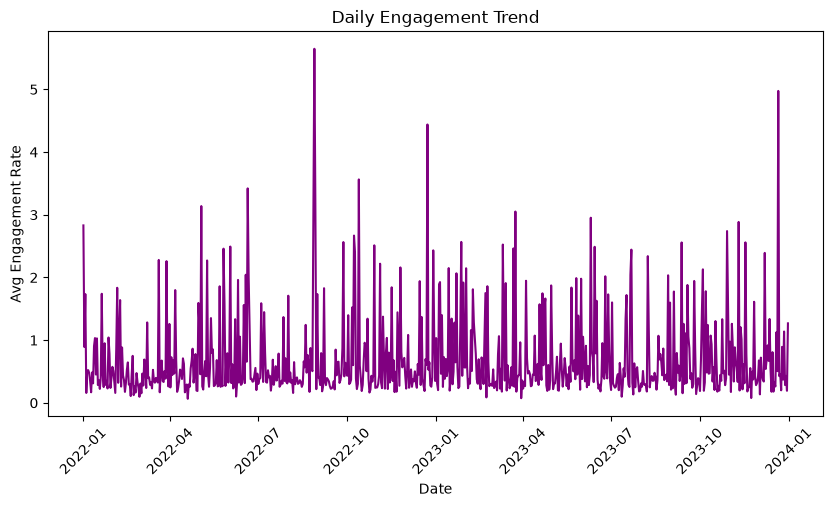

In [25]:
plt.figure(figsize=(8,5))
plt.scatter(df['impression_count'], df['likes'], alpha=0.3, color='teal')
plt.xlabel('Impression Count')
plt.ylabel('Likes')
plt.title('Likes vs Impressions')
plt.show()

daily_engagement = df.groupby(df['posted_at'].dt.date)['engagement_rate'].mean()
plt.figure(figsize=(10,5))
plt.plot(daily_engagement.index, daily_engagement.values, color='purple')
plt.xlabel('Date')
plt.ylabel('Avg Engagement Rate')
plt.title('Daily Engagement Trend')
plt.xticks(rotation=45)
plt.show()

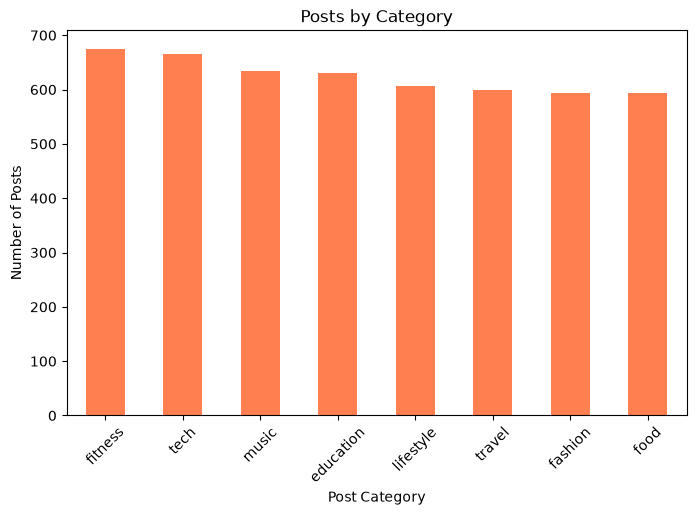

In [26]:
plt.figure(figsize=(8,5))
df['post_category'].value_counts().plot(kind='bar', color='coral')
plt.xlabel('Post Category')
plt.ylabel('Number of Posts')
plt.title('Posts by Category')
plt.xticks(rotation=45)
plt.show()

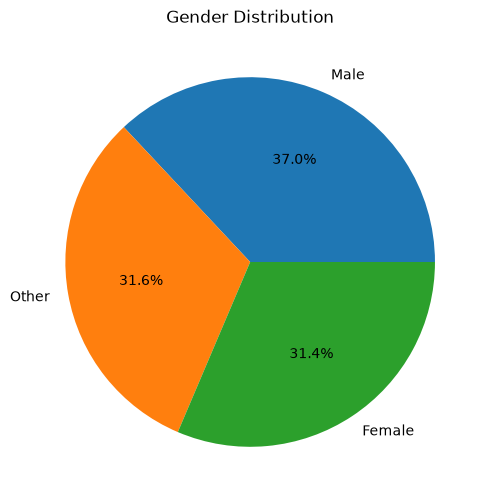

In [27]:
plt.figure(figsize=(6,6))
df['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title('Gender Distribution')
plt.show()

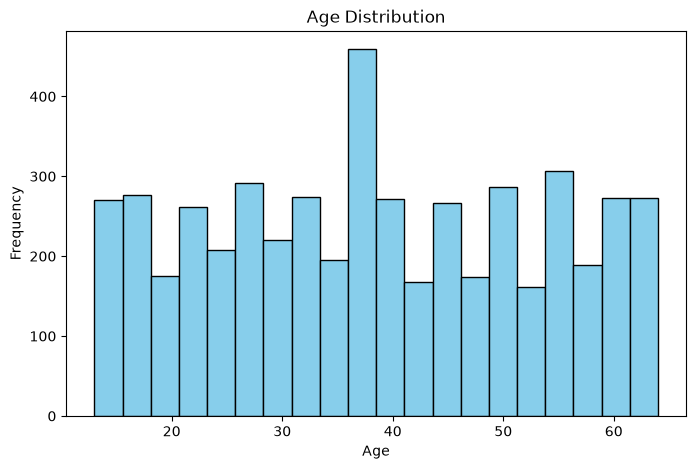

In [28]:
plt.figure(figsize=(8,5))
plt.hist(df['age'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.show()

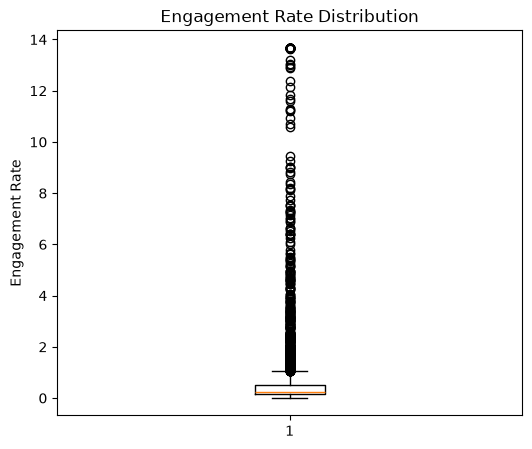

In [29]:
plt.figure(figsize=(6,5))
plt.boxplot(df['engagement_rate'])
plt.ylabel('Engagement Rate')
plt.title('Engagement Rate Distribution')
plt.show()

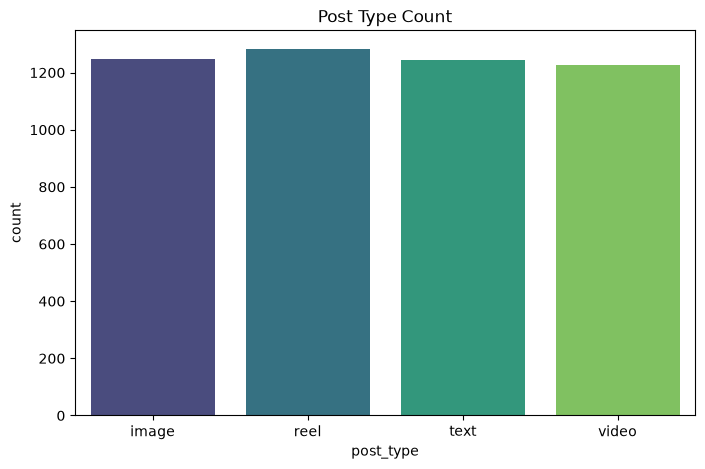

In [30]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='post_type', hue='post_type', palette='viridis', legend=False)
plt.title('Post Type Count')
plt.show()

C:\Users\Golden Dunes\AppData\Local\Temp\ipykernel_7548\367885446.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='post_category', y='likes', palette='magma', errorbar=None)


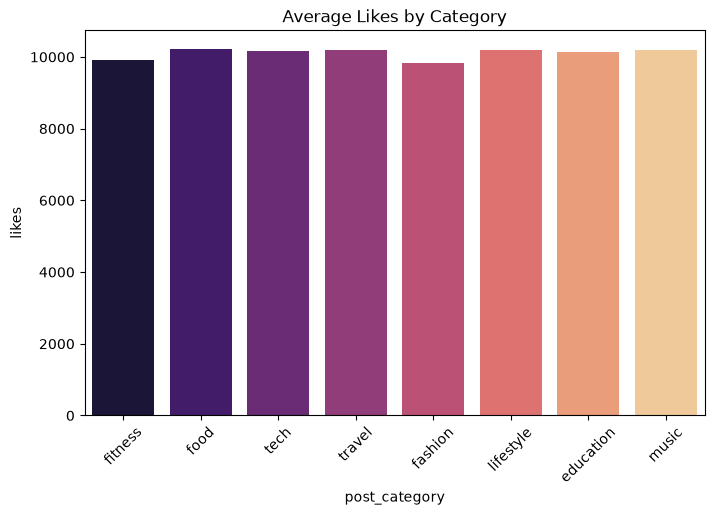

In [31]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='post_category', y='likes', palette='magma', errorbar=None)
plt.title('Average Likes by Category')
plt.xticks(rotation=45)
plt.show()

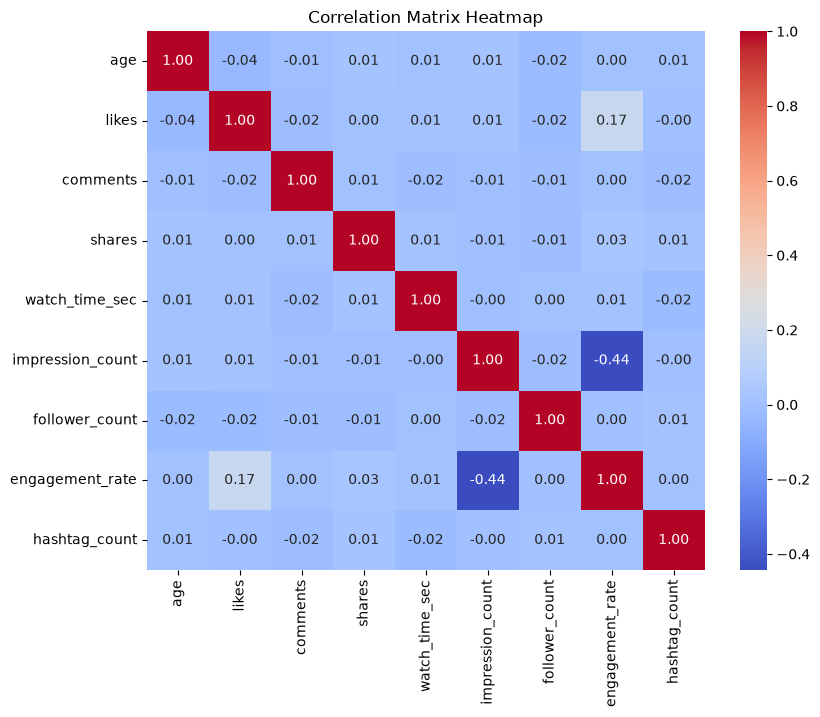

In [32]:
plt.figure(figsize=(9,7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.show()

C:\Users\Golden Dunes\AppData\Local\Temp\ipykernel_7548\2535099655.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='sentiment', y='follower_count', palette='pastel')


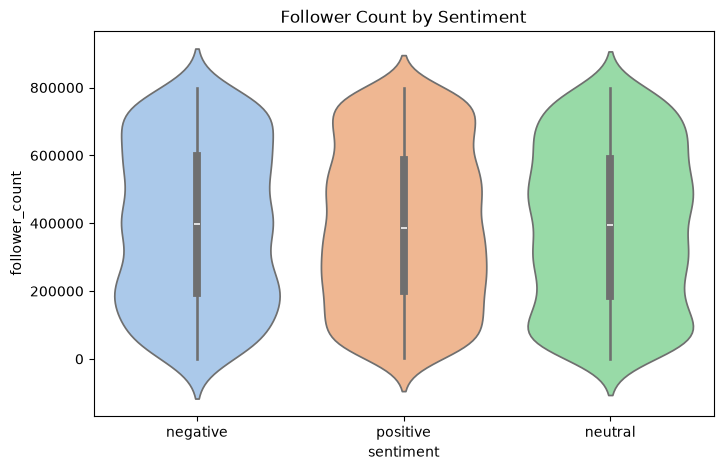

In [33]:
plt.figure(figsize=(8,5))
sns.violinplot(data=df, x='sentiment', y='follower_count', palette='pastel')
plt.title('Follower Count by Sentiment')
plt.show()

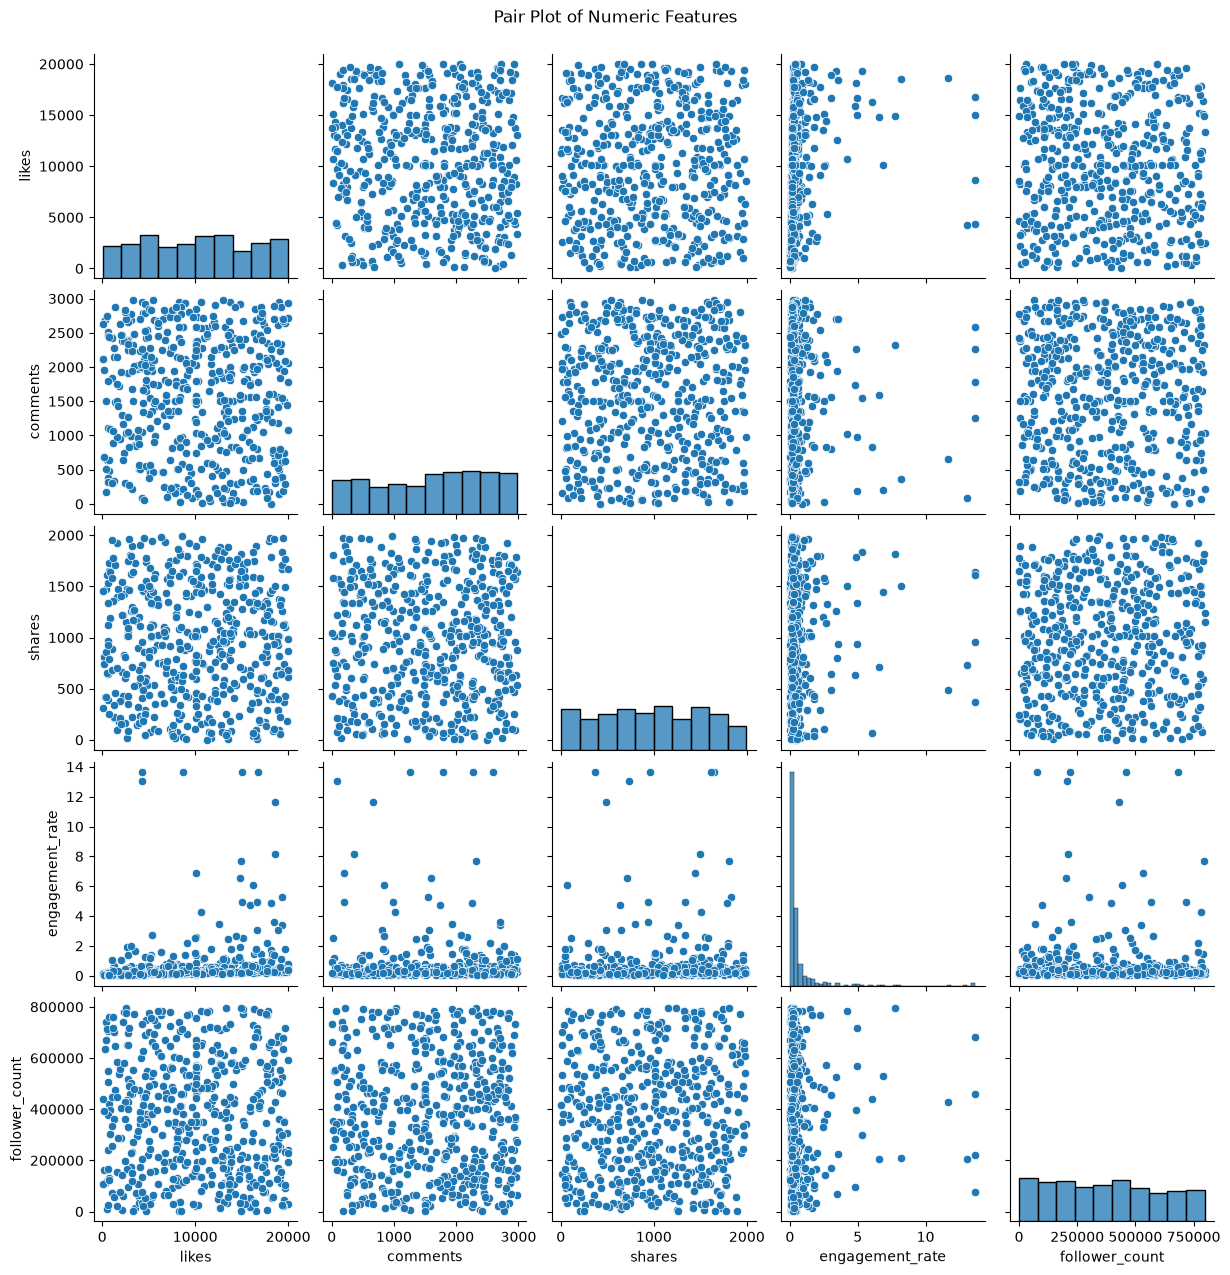

In [34]:
sns.pairplot(df[['likes', 'comments', 'shares', 'engagement_rate', 'follower_count']].sample(500, random_state=42))
plt.suptitle('Pair Plot of Numeric Features', y=1.02)
plt.show()

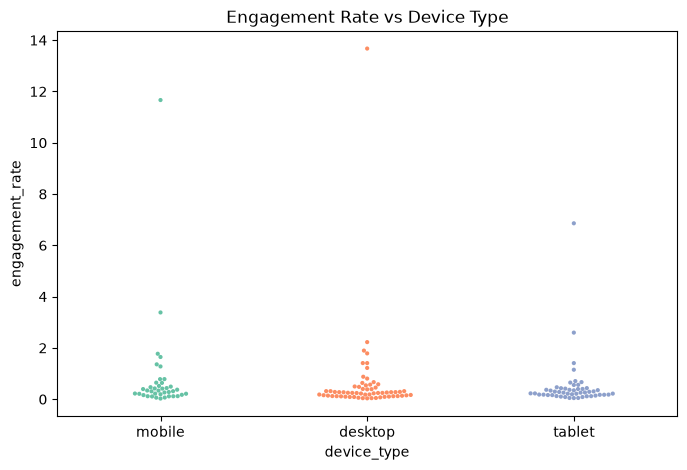

In [35]:
plt.figure(figsize=(8,5))
sns.swarmplot(data=df.sample(150, random_state=42), x='device_type', y='engagement_rate', hue='device_type', palette='Set2', legend=False, size=3)
plt.title('Engagement Rate vs Device Type')
plt.show()

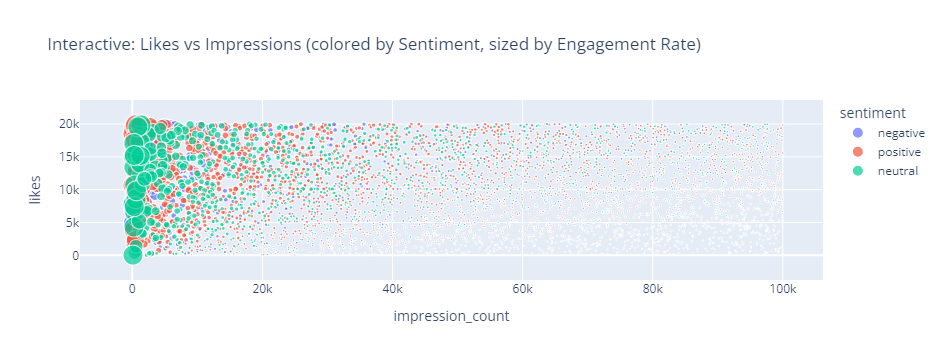

In [36]:
import plotly.express as px
fig = px.scatter(df, x='impression_count', y='likes', color='sentiment', size='engagement_rate', hover_data=['post_type', 'country'], title='Interactive: Likes vs Impressions (colored by Sentiment, sized by Engagement Rate)')
fig.show()

In [37]:
print("Avg engagement_rate by post_type:\n", df.groupby('post_type')['engagement_rate'].mean().sort_values(ascending=False))
print("Avg engagement_rate by post_category:\n", df.groupby('post_category')['engagement_rate'].mean().sort_values(ascending=False))
print("Avg engagement_rate by country:\n", df.groupby('country')['engagement_rate'].mean().sort_values(ascending=False))

Avg engagement_rate by post_type:
 post_type
video    0.751379
text     0.723917
image    0.685445
reel     0.623772
Name: engagement_rate, dtype: float64
Avg engagement_rate by post_category:
 post_category
lifestyle    0.751618
education    0.725089
tech         0.721470
food         0.716452
fitness      0.691112
music        0.682369
fashion      0.641037
travel       0.629642
Name: engagement_rate, dtype: float64
Avg engagement_rate by country:
 country
UAE          0.860280
Australia    0.840878
France       0.837235
Canada       0.708101
Japan        0.696462
Brazil       0.668565
Germany      0.607853
UK           0.590746
India        0.589758
USA          0.560225
Name: engagement_rate, dtype: float64


In [38]:
df['age_group'] = pd.cut(df['age'], bins=[0, 18, 25, 35, 45, 55, 100], labels=['<18', '18-25', '26-35', '36-45', '46-55', '55+'])
print("Avg engagement_rate by age group:\n", df.groupby('age_group', observed=True)['engagement_rate'].mean())
print("Avg engagement_rate by verification status:\n", df.groupby('is_verified')['engagement_rate'].mean())
print("Avg likes by verification status:\n", df.groupby('is_verified')['likes'].mean())

Avg engagement_rate by age group:
 age_group
<18      0.707855
18-25    0.691312
26-35    0.677705
36-45    0.686501
46-55    0.785930
55+      0.622658
Name: engagement_rate, dtype: float64
Avg engagement_rate by verification status:
 is_verified
False    0.693382
True     0.713785
Name: engagement_rate, dtype: float64
Avg likes by verification status:
 is_verified
False    10137.201129
True      9824.533126
Name: likes, dtype: float64


In [39]:
df['hour'] = df['posted_at'].dt.hour
print("Avg impressions by hour of day:\n", df.groupby('hour')['impression_count'].mean().sort_values(ascending=False))
print("Avg watch_time_sec by device_type:\n", df.groupby('device_type')['watch_time_sec'].mean().sort_values(ascending=False))

Avg impressions by hour of day:
 hour
0    50013.7328
Name: impression_count, dtype: float64
Avg watch_time_sec by device_type:
 device_type
mobile     4087.830760
tablet     3979.736429
desktop    3974.792521
Name: watch_time_sec, dtype: float64


In [40]:
print("Avg engagement_rate by sentiment:\n", df.groupby('sentiment')['engagement_rate'].mean().sort_values(ascending=False))
print("\nAvg likes by sentiment:\n", df.groupby('sentiment')['likes'].mean().sort_values(ascending=False))
print("\nAvg comments by sentiment:\n", df.groupby('sentiment')['comments'].mean().sort_values(ascending=False))
print("\nAvg shares by sentiment:\n", df.groupby('sentiment')['shares'].mean().sort_values(ascending=False))

Avg engagement_rate by sentiment:
 sentiment
negative    0.775494
neutral     0.692781
positive    0.666301
Name: engagement_rate, dtype: float64

Avg likes by sentiment:
 sentiment
negative    10208.096875
positive    10180.062077
neutral      9923.194499
Name: likes, dtype: float64

Avg comments by sentiment:
 sentiment
neutral     1528.404060
negative    1516.094792
positive    1480.650617
Name: comments, dtype: float64

Avg shares by sentiment:
 sentiment
negative    1007.307292
positive    1005.086749
neutral      996.565160
Name: shares, dtype: float64


## Summary of Findings — Social Media Engagement Analytics

**Dataset:** 5,000 social media posts. Cleaned by fixing 150 missing values, 
checking for duplicates (none found), and fixing 68 posts with unrealistic 
engagement numbers.

### Content Performance
- **Video** posts get the most engagement, followed by text posts.
- **Lifestyle** content performs best overall; travel content performs worst.
- **UAE, Australia, and France** have the highest engagement rates. 
  USA and India have the lowest.

### User Trends
- Age doesn't change engagement much. The 46-55 age group engages slightly more.
- **Verified accounts** get a bit more engagement, even though they don't 
  always get more likes.

### Behavioral Insights
- Couldn't check "best time of day" — the dataset only has post dates, not times.
- **Mobile** users watch videos slightly longer than tablet or desktop users.

### Sentiment Analysis
- **Negative posts** actually get more engagement and more likes than 
  positive posts. This was surprising.
- Comments and shares are roughly similar across all sentiment types.

### Data Cleaning Notes
- Filled 150 missing values using the median (for numbers) or most common 
  value (for categories).
- Fixed 68 posts with impossible engagement rates by capping them at a 
  realistic maximum.